Import Dependency 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os


from sklearn.model_selection import train_test_split,KFold,cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression ,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

configuration


In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x :f"{x:.3f}")
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'axes.titlesize':10,
    'axes.labelsize':9,
    'xtick.labelsize':8,
    'ytick.labelsize':8
})
RANDOM_STATE=42
CSV_FILE="housing.csv"
target_cols="median_house_value"


Load datasets and basic analysis

In [3]:
df=pd.read_csv(CSV_FILE)

In [4]:
#size of file
size=os.path.getsize(CSV_FILE)
size_mb=round(size/(1024*1024),2)
print(" file size in Mb:", size_mb)

 file size in Mb: 1.36


In [5]:
df.shape

(20640, 10)

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [7]:
df.nunique()

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64

In [8]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [9]:
nums_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=["str"]).columns.tolist()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [11]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [13]:
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
34.110    162
33.980    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [14]:
duplicated_mask=df.duplicated()
number_of_duplicated_value=duplicated_mask.sum()
print(number_of_duplicated_value)

0


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


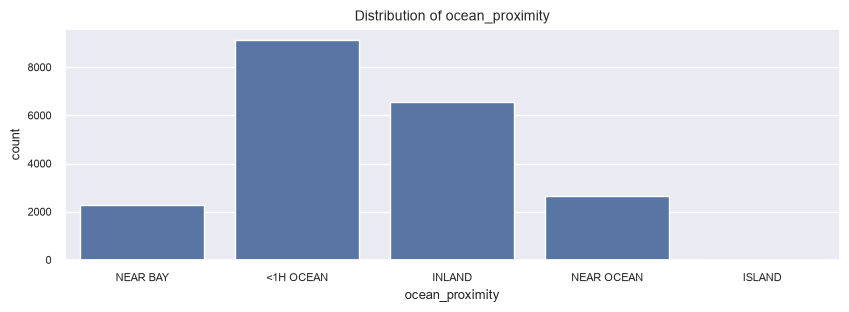

In [16]:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
plt.show()

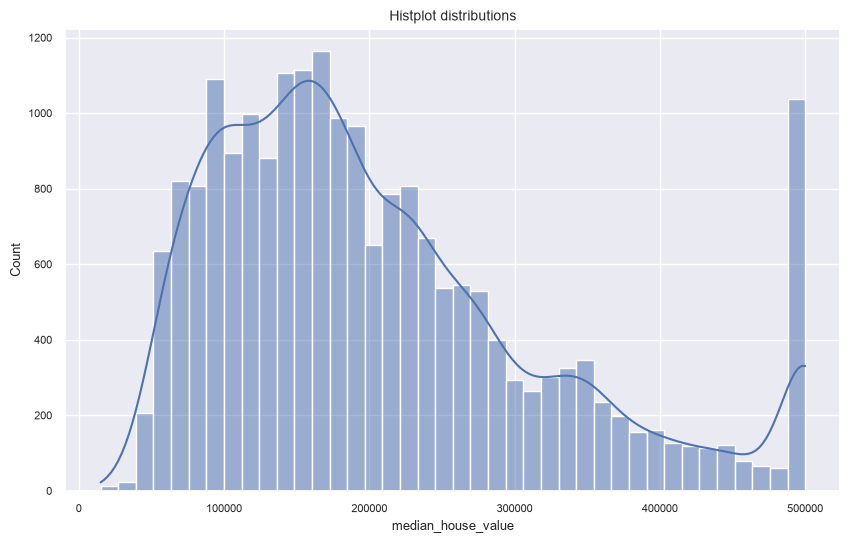

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(x=df[target_cols],bins=40,kde=True)
plt.title("Histplot distributions")
plt.show()

In [18]:
df[target_cols].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
422900.000      1
349400.000      1
425800.000      1
200700.000      1
47000.000       1
Name: count, Length: 3842, dtype: int64

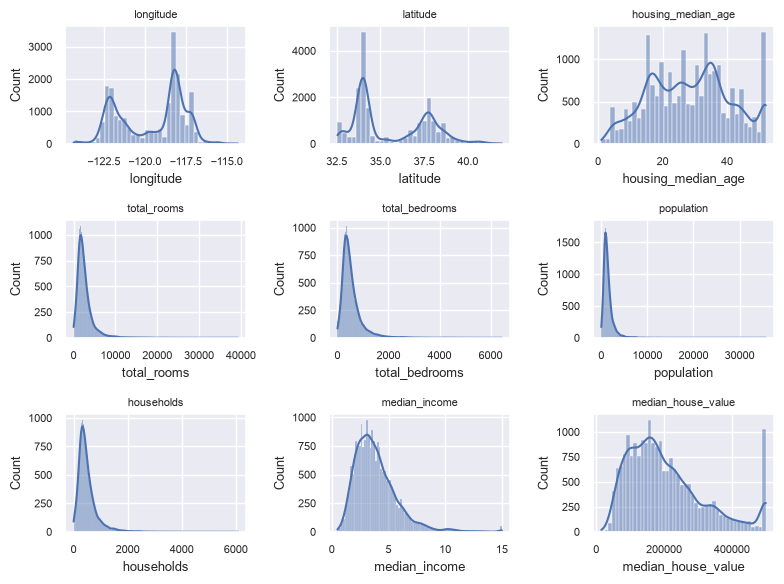

In [19]:
fig,axes=plt.subplots(3,3,figsize=(8,6))
axes=axes.flatten()
for i ,col in enumerate(nums_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()


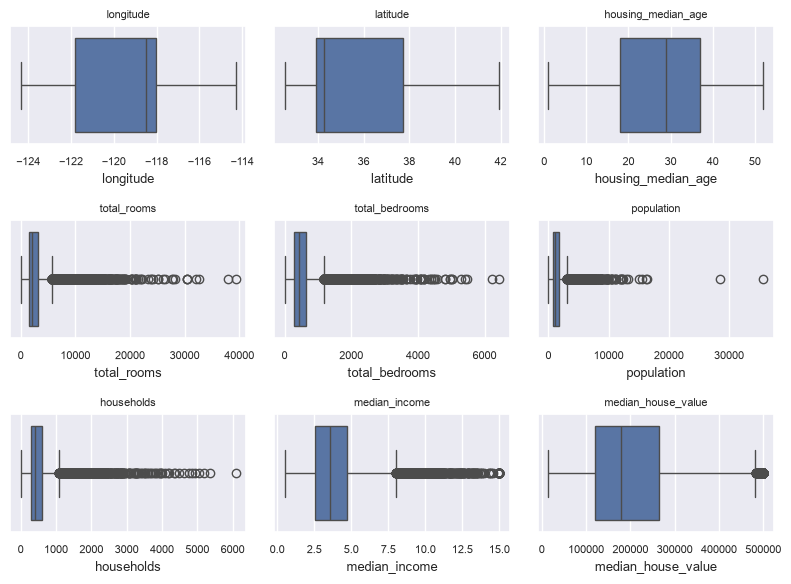

In [20]:
fig,axes=plt.subplots(3,3,figsize=(8,6))
axes=axes.flatten()
for i ,col in enumerate(nums_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()


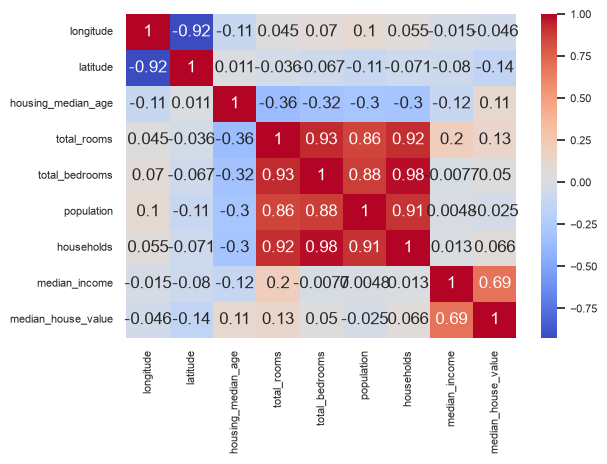

In [21]:
# fig,axes=plt.subplots(3,3,figsize=(8,6))
# axes=axes.flatten()
# for i ,col in enumerate(nums_cols):

sns.heatmap(df[nums_cols].corr(),annot=True,cmap="coolwarm")
# axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()


In [22]:
corr_values_target=df[nums_cols].corr()[target_cols].sort_values(ascending=False)
print(corr_values_target)

median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


Data Preprocessing

In [23]:
x=df.drop(columns=[target_cols])
y=df[target_cols]


In [24]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [25]:
df.groupby(target_cols).value_counts()

median_house_value  longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  ocean_proximity
14999.000           -123.170   40.310    36.000              98.000       28.000          18.000      8.000       0.536          INLAND             1
                    -122.740   39.710    16.000              255.000      73.000          85.000      38.000      1.661          INLAND             1
                    -117.020   36.400    19.000              619.000      239.000         490.000     164.000     2.100          INLAND             1
                    -117.860   34.240    52.000              803.000      267.000         628.000     225.000     4.193          INLAND             1
17500.000           -118.330   34.150    39.000              493.000      168.000         259.000     138.000     2.367          <1H OCEAN          1
                                                                                                         

In [26]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [27]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [28]:
print(X_train.shape)
print(X_test.shape)


(16512, 9)
(4128, 9)


Preprocessing pipeline

In [29]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

In [30]:
nums_cols_pipe=X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_pipe=X_train.select_dtypes(include=["str"]).columns.tolist()

In [31]:
nums_cols_pipe

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [32]:
cat_cols_pipe

['ocean_proximity']

In [33]:
numeric_transformer_pipeline=Pipeline(
    steps=[
    ("impute",SimpleImputer(strategy='median')),  
    ("scaler",StandardScaler())
])

categorical_transformer_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown='ignore'))
    ]
)

#preprocessing pipeline
preprocess=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer_pipeline,nums_cols_pipe),
        ('cat',categorical_transformer_pipeline,cat_cols_pipe)
    ]
    
)

Base Line Model

In [34]:
base_pipeline=Pipeline([
    ('preprocess',preprocess),
    ('model',LinearRegression())
])

In [35]:
# preprocess the data and train the baseline model
base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [36]:
y_train_pred=base_pipeline.predict(X_train)
y_test_pred=base_pipeline.predict(X_test)

In [37]:
y_train[:5]

14196   103000.000
8267    382100.000
17445   172600.000
14265    93400.000
2271     96500.000
Name: median_house_value, dtype: float64

In [38]:
y_train_pred[:5]

array([188628.07724361, 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [39]:
y_train_mse=root_mean_squared_error(y_train,y_train_pred)
y_train_mae=mean_absolute_error(y_train,y_train_pred)
y_train_r2=r2_score(y_train,y_train_pred)


print(" Root Mean squared Error :" ,y_train_mse)
print(" Mean Absolute Error :",y_train_mae )
print(" r2 Score :",y_train_r2 )



 Root Mean squared Error : 68433.93736666226
 Mean Absolute Error : 49594.842094724365
 r2 Score : 0.6496648627123224


In [40]:
y_test_mse=root_mean_squared_error(y_test,y_test_pred)
y_test_mae=mean_absolute_error(y_test,y_test_pred)
y_test_r2=r2_score(y_test,y_test_pred)


print(" Root Mean squared Error :" ,y_test_mse)
print(" Mean Absolute Error :",y_test_mae )
print(" r2 Score :",y_test_r2 )



 Root Mean squared Error : 70059.19333925014
 Mean Absolute Error : 50670.48923565362
 r2 Score : 0.6254382675296266


Model selection and optimization

In [41]:
model_selection={
    
    "LinearRegression":LinearRegression(),
    
    "Ridge":Ridge(
        random_state=RANDOM_STATE
        ),
    
    "Lasso":Lasso(
        random_state=RANDOM_STATE,
        max_iter=10000
        ),
    "RandomForest":RandomForestRegressor(),
    
    "HistGB":HistGradientBoostingRegressor()
}

In [42]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)


In [43]:
scoring={
    'rmse':'neg_root_mean_squared_error',
    'mae':'neg_mean_absolute_error',
    'r2':'r2'
}

In [44]:
rows=[]
for name,model in model_selection.items():
    pipe=Pipeline(
        steps=[
            ("preprocess",preprocess),
            ('model',model  )
        ]
    )
     
    scores=cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
         
        )
    rows.append(
        {
            'model':name,
            "cv_score_rmse":-scores['test_rmse'].mean(),
            "cv_score_mae":-scores['test_mae'].mean(),
            "cv_score_r2":-scores['test_r2'].mean(),
            
            
        }
    )
    
    
#sort based on lowest rmse value
cv_results=pd.DataFrame(rows).sort_values('cv_score_rmse')
print("===cv Model Comparison===")
print(cv_results)


===cv Model Comparison===
              model  cv_score_rmse  cv_score_mae  cv_score_r2
4            HistGB      48222.391     32281.584       -0.826
3      RandomForest      49424.233     32260.201       -0.817
1             Ridge      68595.617     49664.331       -0.648
2             Lasso      68603.233     49667.263       -0.648
0  LinearRegression      68604.163     49667.159       -0.648


In [45]:
scores.keys()

dict_keys(['fit_time', 'score_time', 'test_rmse', 'test_mae', 'test_r2'])

In [46]:
cv_results

,model,cv_score_rmse,cv_score_mae,cv_score_r2
4,HistGB,48222.391,32281.584,-0.826
3,RandomForest,49424.233,32260.201,-0.817
1,Ridge,68595.617,49664.331,-0.648
2,Lasso,68603.233,49667.263,-0.648
0,LinearRegression,68604.163,49667.159,-0.648


In [47]:
best_rows=cv_results.sort_values("cv_score_rmse").iloc[0]


In [48]:
best_model_name=best_rows['model']
best_rmse=best_rows['cv_score_rmse']

print("Model", best_model_name)
print("CV RMse", best_rmse)

Model HistGB
CV RMse 48222.390505464646


Best Model Hist
Gradient Boosting Rgressor

Hyperparameter tunning


In [49]:
best_pipe=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ('model',HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [50]:
#HYPER PARAMETER TUNNING

param_grid={
    'model__learning_rate':[0.03,0.05,0.1],
    'model__max_depth':[None,3,6],
    "model__min_samples_leaf":[20,50,100],
    'model__l2_regularization':[0.0,0.1,1.0],
    "model__max_leaf_nodes":[15,31,63]
}

In [51]:
gscv=GridSearchCV(
    estimator=best_pipe,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    verbose=1
    
)

In [52]:
gscv.fit(X_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.S

In [53]:
print("---------Tuned best parameters-----------")
print("Best Cv scores: ",-gscv.best_score_)
print("Best Params :", gscv.best_params_) 

---------Tuned best parameters-----------
Best Cv scores:  47327.96653299736
Best Params : {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


In [54]:
best_hyperparmas=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ('model',HistGradientBoostingRegressor(
            l2_regularization=0.0,
            learning_rate=0.1,
            max_leaf_nodes=63,
            max_depth=None,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        )
         )
    ]
)

In [55]:
gscv.best_estimator_.predict(X_train)

array([127448.18489421, 370423.40407504, 197143.41580318, ...,
       254873.91929693, 261643.17808827, 324148.09438152], shape=(16512,))

In [56]:
best_hyperparmas.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [57]:
#train best mode on entire training data can also be done with
#refit =true
train_final_pred=best_hyperparmas.predict(X_train)

train_final_rmse=root_mean_squared_error(y_train,train_final_pred)
train_final_mae=mean_absolute_error(y_train,train_final_pred)
train_final_r2=r2_score(y_train,train_final_pred)



print("-------Final Model (tuned HgBR) train performance-------")
print(f"Rmse : {train_final_rmse:.3f}")
print(f"mae : {train_final_mae:.3f}")
print(f"R2_score : {train_final_r2:.3f}")


-------Final Model (tuned HgBR) train performance-------
Rmse : 36062.562
mae : 24559.875
R2_score : 0.903


In [58]:

test_final_pred=best_hyperparmas.predict(X_test)

test_final_rmse=root_mean_squared_error(y_test,test_final_pred)
test_final_mae=mean_absolute_error(y_test,test_final_pred)
test_final_r2=r2_score(y_test,test_final_pred)



print("-------Final Model (tuned HgBR) train performance-------")
print(f"Rmse : {test_final_rmse:.3f}")
print(f"mae : {test_final_mae:.3f}")
print(f"R2_score : {test_final_r2:.3f}")


-------Final Model (tuned HgBR) train performance-------
Rmse : 46923.352
mae : 30990.885
R2_score : 0.832


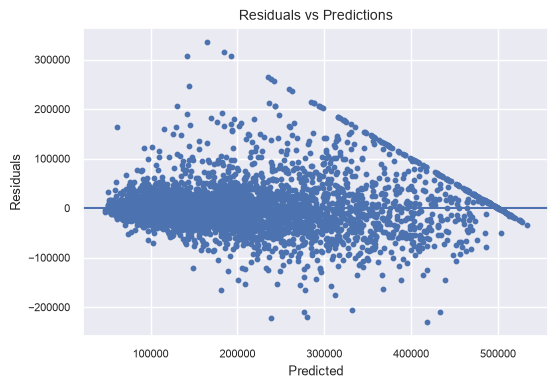

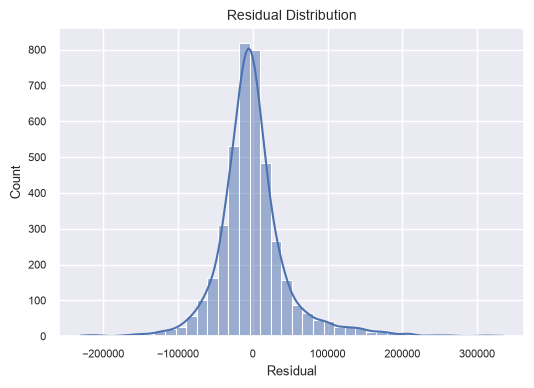

In [59]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(8)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt. show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt. show()


In [73]:
X_test.loc[20046]

longitude            -119.010
latitude               36.060
housing_median_age     25.000
total_rooms          1505.000
total_bedrooms            NaN
population           1392.000
households            359.000
median_income           1.681
ocean_proximity        INLAND
Name: 20046, dtype: object

In [ ]:
def house_price(
    model,
    longitude:float,
    latitude:float,             
    housing_median_age:float,
    total_rooms:float,  
    total_bedrooms:float,            
    population:float,      
    households:float,           
    median_income:float,           
    ocean_proximity:str 
):
    new_row=pd.DataFrame([{
    "longitude":longitude,
    "latitude":latitude,             
    "housing_median_age":housing_median_age,
    "total_rooms":total_rooms,  
    "total_bedrooms":total_bedrooms,            
    "population":population,      
    "households":households,           
    "median_income":median_income,           
    "ocean_proximity":ocean_proximity 
        
        
    }])     
    

    price_of_house=model.predict(new_row)
    print("Price of your House:",price_of_house)
    

In [ ]:
dict={}
for i,col in enumerate(X_test.columns,0):
    
    dict[col]=X_test.loc[20046].tolist()[i]
    

In [98]:

house_price(best_hyperparmas,longitude=-119.01,
 latitude= np.float64(36.06),
 housing_median_age=np.float64(25.0),
 total_rooms=np.float64(1505.0),
 total_bedrooms=np.float64(6),
 population=np.float64(1392.0),
 households=np.float64(359.0),
 median_income=np.float64(1.6812),
 ocean_proximity='INLAND')

Price of your House: [52893.42896276]
